In [115]:
import pandas as pd
import seaborn as sns
import time
import random
import matplotlib.pyplot as plt

In [116]:
# importing the file with encoding UTF-8
df = pd.read_csv('/Users/shahadat/Downloads/laptops.csv', encoding='UTF-8')

In [117]:
# viewing some rows
df.head(5)

,Id,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,6571244,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339
1,7287764,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898
2,3362737,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575
3,9722156,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537
4,8550527,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,1803


In [118]:
df.nunique()

Id                  1303
Company               19
Product              618
TypeName               6
Inches                18
ScreenResolution      40
Cpu                  118
Ram                    9
Memory                39
Gpu                  110
OpSys                  9
Weight               179
Price                703
dtype: int64

In [119]:
# checking its shape
df.shape

(1303, 13)

In [120]:
# checking the data types
df.dtypes

Id                    int64
Company              object
Product              object
TypeName             object
Inches              float64
ScreenResolution     object
Cpu                  object
Ram                  object
Memory               object
Gpu                  object
OpSys                object
Weight               object
Price                 int64
dtype: object

In [121]:
# confirming there is no null values
df.isna().sum()

Id                  0
Company             0
Product             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price               0
dtype: int64

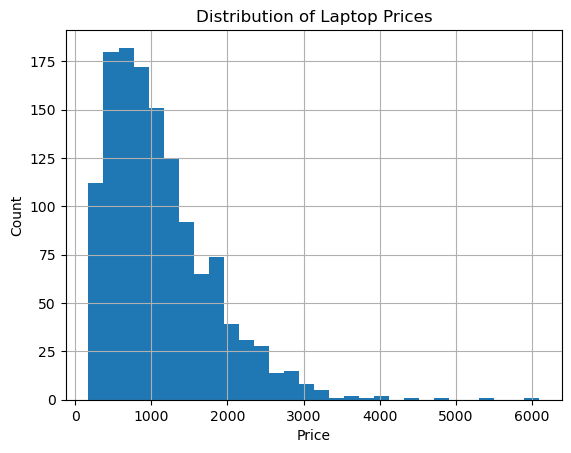

In [122]:
# checking the pricing of the dataset
df['Price'].hist(bins=30)
plt.xlabel("Price")
plt.ylabel("Count")
plt.title("Distribution of Laptop Prices")
plt.show()

### 📊 Distribution of Laptop Prices
The histogram above shows the distribution of laptop prices in the dataset.

- Most laptops are priced between \$500 and \$1500, which is the most common segment.  
- The distribution is right-skewed, with fewer laptops in the higher price range (up to ~\$6000).  
- The peak is around \$600–\$1000, showing that budget and mid-range laptops dominate.  
- Premium laptops (above \$2000) exist but are less common, mostly from high-end brands.


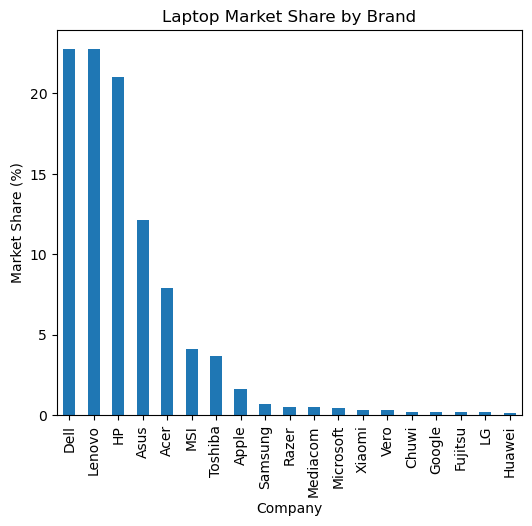

In [123]:
# checking the market share got by brands

(df['Company'].value_counts(normalize=True) * 100).plot(kind='bar', figsize=(6,5))

plt.ylabel("Market Share (%)")
plt.title("Laptop Market Share by Brand")
plt.show()


### 💻 Laptop Market Share by Brand
The bar chart above shows the market share of different laptop brands in terms of the number of models available in the dataset.

- Dell, Lenovo, and HP dominate the dataset, together making up nearly two-thirds of all laptop models.  
- Asus and Acer also hold significant portions, representing the mid-tier brands.  
- Brands like MSI, Toshiba, and Apple have a smaller share compared to the top three, but they still contribute notable product lines.  
- Premium or niche brands such as Razer, Microsoft, Samsung, and LG hold only a small fraction of the market share.  
- Some other brands (e.g., Huawei, Google, Fujitsu) have very limited representation in the dataset.  

Overall, the distribution indicates that the market is heavily concentrated among a few leading companies, with Dell, Lenovo, and HP being the dominant players.


## Handle Categorical Features

Cpu, Gpu, OpSys → text columns.

can simplify them by extracting key information (e.g., CPU brand, GPU brand,cpu_generation, OS type).


In [124]:
# extracting the cpu name & generation, store it different columns
df['Cpu_brand'] = df['Cpu'].apply( lambda x : x.split()[0])
df['cpu_generation'] = df['Cpu'].apply(lambda x: x.split()[2])
df['OsType'] = df['OpSys'].apply( lambda x: "Windows" if x.split()[0] == "Windows"  else x)

df.head(5)

,Id,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Cpu_brand,cpu_generation,OsType
0,6571244,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339,Intel,i5,macOS
1,7287764,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898,Intel,i5,macOS
2,3362737,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575,Intel,i5,No OS
3,9722156,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537,Intel,i7,macOS
4,8550527,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,1803,Intel,i5,macOS


In [125]:
df['gpu_brand'] = df['Gpu'].apply(lambda x: x.split()[0])
df['gpu_brand'].value_counts()

gpu_brand
Intel     722
Nvidia    400
AMD       180
ARM         1
Name: count, dtype: int64

In [126]:
df['gpu_type'] = df['gpu_brand'].apply(lambda x: 'integrated' if x.lower() == 'intel' else 'dedicated')
df['gpu_type'].value_counts()

gpu_type
integrated    722
dedicated     581
Name: count, dtype: int64

In [127]:
df['Memory'].value_counts()

Memory
256GB SSD                        412
1TB HDD                          223
500GB HDD                        132
512GB SSD                        118
128GB SSD +  1TB HDD              94
128GB SSD                         76
256GB SSD +  1TB HDD              73
32GB Flash Storage                38
2TB HDD                           16
64GB Flash Storage                15
512GB SSD +  1TB HDD              14
1TB SSD                           14
256GB SSD +  2TB HDD              10
1.0TB Hybrid                       9
256GB Flash Storage                8
16GB Flash Storage                 7
32GB SSD                           6
180GB SSD                          5
128GB Flash Storage                4
512GB SSD +  2TB HDD               3
16GB SSD                           3
512GB Flash Storage                2
1TB SSD +  1TB HDD                 2
256GB SSD +  500GB HDD             2
128GB SSD +  2TB HDD               2
256GB SSD +  256GB SSD             2
512GB SSD +  256GB SSD         

### 🧹 Clean & Convert Numerical Columns

There are 4 important columns in the dataset that need cleaning before analysis:

- **Ram** → Currently stored as strings with `"GB"`. We will remove the unit and convert this into integers.  
- **Weight** → Stored as strings with `"kg"`. We will remove the unit and convert this into floats.  
- **Memory** → Contains both the amount and type of storage (HDD, SSD, Hybrid, Flash). Will split this column into separate numeric features such as `HDD`, `SSD`, and `Flash_Storage`.  
- **Price** → Already numeric, so no transformation is needed.  

Cleaning these columns ensures that they can be used in statistical analysis and machine learning models.

In [128]:
df['Ram'].value_counts()

Ram
8GB     619
4GB     375
16GB    200
6GB      41
12GB     25
2GB      22
32GB     17
24GB      3
64GB      1
Name: count, dtype: int64

In [129]:
# remove the units and convert the type of "Ram"
df['Ram'] = df['Ram'].apply( lambda x: x.replace('GB',"")).astype(int)

In [130]:
df['Weight'].value_counts()

Weight
2.2kg     121
2.1kg      58
2.4kg      44
2.3kg      41
2.5kg      38
         ... 
3.25kg      1
4.7kg       1
1.55kg      1
1.18kg      1
4.0kg       1
Name: count, Length: 179, dtype: int64

In [131]:
# remove the units and convert the type of "Weight"
df['Weight'] = df['Weight'].apply( lambda x: x.replace('kg',"")).astype(float)

In [132]:
# some data contains like 1.0 TB in values, so first replace those with blank
df['memory_size'] = df['Memory'].apply(lambda x: x.replace('.0',""))

# Normalize units, Convert "TB" → "000GB" (so 1TB = 1000GB), Remove "GB" text
df['memory_size'] = df['memory_size'].apply(lambda x: x.replace('TB','000'))
df['memory_size'] = df['memory_size'].apply(lambda x: x.replace('GB',''))
df['memory_size'].value_counts()

memory_size
256 SSD                         412
1000 HDD                        224
500 HDD                         132
512 SSD                         118
128 SSD +  1000 HDD              94
128 SSD                          76
256 SSD +  1000 HDD              73
32 Flash Storage                 38
2000 HDD                         16
64 Flash Storage                 15
512 SSD +  1000 HDD              14
1000 SSD                         14
256 SSD +  2000 HDD              10
1000 Hybrid                       9
256 Flash Storage                 8
16 Flash Storage                  7
32 SSD                            6
180 SSD                           5
128 Flash Storage                 4
512 SSD +  2000 HDD               3
16 SSD                            3
512 Flash Storage                 2
1000 SSD +  1000 HDD              2
256 SSD +  500 HDD                2
128 SSD +  2000 HDD               2
256 SSD +  256 SSD                2
512 SSD +  256 SSD                1
512 SSD +  512 S

In [133]:
# create empty columns
df['memory_hdd'] = 0
df['memory_ssd'] = 0
df['memory_hybrid'] = 0
df['memory_flash_storage'] = 0

# looping through each memory_size
for row in df.itertuples():
    parts = row.memory_size.split('+')  # split into items
    for item in parts:
        item = item.lower()
        item = item.strip() # removes extra spaces
        size = int(item.split()[0]) # take the number before type
        if 'hdd' in item:
            df.loc[row.Index, 'memory_hdd'] += size
        elif 'ssd' in item:
            df.loc[row.Index, 'memory_ssd'] += size
        elif 'hybrid' in item:
            df.loc[row.Index, 'memory_hybrid'] += size
        elif 'flash' in item:
            df.loc[row.Index, 'memory_flash_storage'] += size
#df['Memory'].value_counts()
df.loc[:, df.columns[-4:]].value_counts()

memory_hdd  memory_ssd  memory_hybrid  memory_flash_storage
0           256         0              0                       412
1000        0           0              0                       224
500         0           0              0                       132
0           512         0              0                       120
1000        128         0              0                        94
0           128         0              0                        76
1000        256         0              0                        73
0           0           0              32                       38
2000        0           0              0                        17
0           0           0              64                       15
1000        512         0              0                        14
0           1000        0              0                        14
2000        256         0              0                        10
0           0           1000           0                         9
  

In [134]:
df['ScreenResolution'].value_counts()

ScreenResolution
Full HD 1920x1080                                507
1366x768                                         281
IPS Panel Full HD 1920x1080                      230
IPS Panel Full HD / Touchscreen 1920x1080         53
Full HD / Touchscreen 1920x1080                   47
1600x900                                          23
Touchscreen 1366x768                              16
Quad HD+ / Touchscreen 3200x1800                  15
IPS Panel 4K Ultra HD 3840x2160                   12
IPS Panel 4K Ultra HD / Touchscreen 3840x2160     11
4K Ultra HD / Touchscreen 3840x2160               10
4K Ultra HD 3840x2160                              7
Touchscreen 2560x1440                              7
IPS Panel 1366x768                                 7
IPS Panel Quad HD+ / Touchscreen 3200x1800         6
IPS Panel Retina Display 2560x1600                 6
IPS Panel Retina Display 2304x1440                 6
Touchscreen 2256x1504                              6
IPS Panel Touchscreen 2560x14

### 🖥️ Feature Engineering: Screen Resolution

The `ScreenResolution` column contains mixed information such as:
- Display resolution (e.g., `1920x1080`, `1366x768`, `3840x2160`)
- Panel type (`IPS`, `Retina`)
- Touchscreen information (`Touchscreen` / non-touchscreen)

Since it is a text column, it cannot be directly used in analysis or modeling.  
To make it useful, will extract the following features:

- **Touchscreen** → Binary feature (1 = touchscreen, 0 = non-touch)  
- **IPS Panel** → Binary feature indicating if the display uses IPS technology  
- **Retina Display** → Binary feature for Apple-specific Retina displays  
- **ResolutionX and ResolutionY** → Numeric width and height of the screen  
- **PPI (Pixels Per Inch)** → Calculated from resolution and screen size (`Inches`) to measure sharpness  
- **Resolution Type** → Categorical feature grouping screens into `HD`, `Full HD`, `2K`, `Retina`, and `4K`  

These engineered features will allow us to better analyze laptop pricing trends and improve model performance.


In [135]:
features = ['ips', 'retina', 'touchscreen']
for keyword in features:
    df[keyword] = df['ScreenResolution'].apply(lambda x: 1 if keyword in str(x.split()).lower() else 0)

In [136]:
df['resolution_x'] = pd.to_numeric(
    df['ScreenResolution'].str.extract(r'(\d+)[x×](\d+)')[0], 
    errors='coerce'
)

df['resolution_y'] = pd.to_numeric(
    df['ScreenResolution'].str.extract(r'(\d+)[x×](\d+)')[1], 
    errors='coerce'
)

In [137]:
df.isna().sum()

Id                      0
Company                 0
Product                 0
TypeName                0
Inches                  0
ScreenResolution        0
Cpu                     0
Ram                     0
Memory                  0
Gpu                     0
OpSys                   0
Weight                  0
Price                   0
Cpu_brand               0
cpu_generation          0
OsType                  0
gpu_brand               0
gpu_type                0
memory_size             0
memory_hdd              0
memory_ssd              0
memory_hybrid           0
memory_flash_storage    0
ips                     0
retina                  0
touchscreen             0
resolution_x            0
resolution_y            0
dtype: int64

In [138]:
df.head()

,Id,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,...,memory_size,memory_hdd,memory_ssd,memory_hybrid,memory_flash_storage,ips,retina,touchscreen,resolution_x,resolution_y
0,6571244,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,...,128 SSD,0,128,0,0,1,1,0,2560,1600
1,7287764,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,...,128 Flash Storage,0,0,0,128,0,0,0,1440,900
2,3362737,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,...,256 SSD,0,256,0,0,0,0,0,1920,1080
3,9722156,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,...,512 SSD,0,512,0,0,1,1,0,2880,1800
4,8550527,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,...,256 SSD,0,256,0,0,1,1,0,2560,1600


In [139]:
df.columns

Index(['Id', 'Company', 'Product', 'TypeName', 'Inches', 'ScreenResolution',
       'Cpu', 'Ram', 'Memory', 'Gpu', 'OpSys', 'Weight', 'Price', 'Cpu_brand',
       'cpu_generation', 'OsType', 'gpu_brand', 'gpu_type', 'memory_size',
       'memory_hdd', 'memory_ssd', 'memory_hybrid', 'memory_flash_storage',
       'ips', 'retina', 'touchscreen', 'resolution_x', 'resolution_y'],
      dtype='object')

In [140]:
df_cutted = df[['Id','Company', 'Product','TypeName','Inches','Ram','Weight','Cpu_brand','cpu_generation','OsType','gpu_brand','gpu_type','memory_hdd','memory_ssd','memory_hybrid','memory_flash_storage','ips','retina','touchscreen','resolution_x','resolution_y','Price']]
df_cutted.head()

,Id,Company,Product,TypeName,Inches,Ram,Weight,Cpu_brand,cpu_generation,OsType,...,memory_hdd,memory_ssd,memory_hybrid,memory_flash_storage,ips,retina,touchscreen,resolution_x,resolution_y,Price
0,6571244,Apple,MacBook Pro,Ultrabook,13.3,8,1.37,Intel,i5,macOS,...,0,128,0,0,1,1,0,2560,1600,1339
1,7287764,Apple,Macbook Air,Ultrabook,13.3,8,1.34,Intel,i5,macOS,...,0,0,0,128,0,0,0,1440,900,898
2,3362737,HP,250 G6,Notebook,15.6,8,1.86,Intel,i5,No OS,...,0,256,0,0,0,0,0,1920,1080,575
3,9722156,Apple,MacBook Pro,Ultrabook,15.4,16,1.83,Intel,i7,macOS,...,0,512,0,0,1,1,0,2880,1800,2537
4,8550527,Apple,MacBook Pro,Ultrabook,13.3,8,1.37,Intel,i5,macOS,...,0,256,0,0,1,1,0,2560,1600,1803


## Column Name Standardization
   To ensure consistency, all column names were cleaned:
   - Removed leading/trailing spaces
   - Replaced spaces with underscores (' ' → '_')
   - Converted CamelCase into snake_case (e.g., CpuBrand → cpu_brand)\
   - Converted everything to lowercase

In [141]:
df_cutted.columns = (
    df_cutted.columns
    .str.strip()
    .str.replace(' ','_')
    .str.replace(r'(?<!^)(?=[A-Z])','_', regex=True)
    .str.lower()
)

In [142]:
df_cutted.to_csv('laptop_cutted.csv', index=False)